# 03 · Optimisation and validation

Search on train, select on validation, measure selection bias (Deflated Sharpe, PBO), unseal the test set exactly once, walk forward, and stress the result with Monte Carlo.

> **Real data instead of the synthetic market.** Replace the generation cell with
> ```python
> from pumpfun_hft.collectors.storage import ParquetEventStore
> from pumpfun_hft.backtester.replay import load_metadata
> events = ParquetEventStore(settings.paths.events_dir).read()
> metadata = load_metadata(settings.paths.metadata_dir / "tokens.parquet")
> ```
> after running `collect-history` (or `stream`) from the CLI.


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, polars as pl, matplotlib.pyplot as plt
from pumpfun_hft.core.config import load_settings
from pumpfun_hft.collectors.synthetic import SyntheticMarket

pl.Config.set_tbl_rows(12); pl.Config.set_tbl_cols(14); pl.Config.set_fmt_str_lengths(40); pl.Config.set_tbl_width_chars(160)
BLUE, ORANGE, AQUA, YELLOW, RED, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e34948", "#898781"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e1e0d9", "grid.linewidth": 0.6, "axes.edgecolor": "#c3c2b7", "font.size": 9})


In [2]:
import tempfile
settings = load_settings(None, {"synthetic.duration_hours": 24, "optimizer.n_workers": 2})
data = SyntheticMarket(settings).generate()
events = data.events
from pathlib import Path
meta_path = str(Path(tempfile.mkdtemp()) / "tokens.parquet"); data.metadata.write_parquet(meta_path)
from pumpfun_hft.optimizer.splits import make_splits
start, end = int(events["ts_ms"].min()), int(events["ts_ms"].max()) + 1
print(make_splits(start, end, settings.optimizer.splits).describe())

['train: 2026-09-01T00:03:08.801Z -> 2026-09-01T11:49:07.101Z', 'validation: 2026-09-01T12:19:07.101Z -> 2026-09-01T17:01:30.421Z', 'test: <sealed>', 'live_sim: <sealed>']


Train / validation / test / live-sim are consecutive, embargoed time ranges. Test and live-sim are **sealed**: reading them requires an explicit, logged `unseal`.

In [3]:
from pumpfun_hft.optimizer.study import OptimizationStudy
study = OptimizationStudy(settings, events, meta_path, "smart_money", method="bayesian", n_trials=12)
res = study.run(final_evaluation=True)
tr = pl.DataFrame([{"trial": t["number"], **t["params"], "score": t["score"], "trades": (t["metrics"] or {}).get("n_trades")}
                   for t in res.trials])
tr.sort("score", descending=True).head(8)

trial,min_smart_buyers,min_smart_score,window_s,score,trades
i64,i64,f64,f64,f64,i64
7,2,0.745016,22.743182,78.622175,128
11,2,0.744848,27.599202,76.475116,128
4,2,0.678031,156.318995,65.999835,148
6,3,0.895584,72.439522,57.206685,113
0,4,0.858886,234.94885,56.549396,114
10,2,0.698906,48.103163,53.915221,142
8,1,0.705956,145.199747,48.312334,155
5,3,0.8982,239.871957,47.495596,117


In [4]:
print("selected:", res.selected_params)
print(f"train return {res.selected_train_metrics.get('total_return', float('nan')):+.4f} · "
      f"validation return {res.selected_val_metrics.get('total_return', float('nan')):+.4f}")
print(f"Deflated Sharpe {res.dsr['dsr']:.3f} (per-period Sharpe {res.dsr['sharpe']:.3f} vs expected max {res.dsr['sr_star']:.3f})")
print(f"PBO {res.pbo['pbo']:.2f} over {int(res.pbo['n_combinations'])} CSCV combinations")
print(f"sealed test: return {res.test_metrics.get('total_return', float('nan')):+.4f}, trades {res.test_metrics.get('n_trades')}")
print("unseal log:", [u["reason"] for u in res.unseal_log])

selected: {'min_smart_buyers': 3, 'min_smart_score': 0.6212129707277254, 'window_s': 90.74342750922426}
train return +0.0902 · validation return +0.0327
Deflated Sharpe 0.782 (per-period Sharpe 0.061 vs expected max 0.034)
PBO 0.47 over 12870 CSCV combinations
sealed test: return +0.0234, trades 47
unseal log: ["final evaluation of smart_money {'min_smart_buyers': 3, 'min_smart_score': 0.6212129707277254, 'window_s': 90.74342750922426}", "live-simulation of smart_money {'min_smart_buyers': 3, 'min_smart_score': 0.6212129707277254, 'window_s': 90.74342750922426}"]


A PBO near or above 0.5 means the in-sample winner is no better than a coin flip out of sample: the search is fitting noise, whatever the train score says.

In [5]:
from pumpfun_hft.optimizer.overfitting import pbo_cscv
rng = np.random.default_rng(0)
noise = rng.normal(0, 1, size=(400, 30))                          # 30 strategies with zero true edge
edge = noise.copy(); edge[:, 0] += 0.35                           # one strategy with a real edge
print("PBO, pure noise :", round(pbo_cscv(noise)["pbo"], 2))
print("PBO, one real edge:", round(pbo_cscv(edge)["pbo"], 2))

PBO, pure noise : 0.58


PBO, one real edge: 0.0


## Walk-forward

In [6]:
from pumpfun_hft.optimizer.study import WalkForwardAnalysis
wf = WalkForwardAnalysis(settings, events, meta_path, "smart_money", method="random", n_trials=6).run()
print(f"walk-forward efficiency {wf.wfe:.2f} · stitched out-of-sample return {wf.oos_total_return:+.4f}")
wf.frame().select([c for c in wf.frame().columns if c in ("fold", "is_score", "val_score", "oos_score", "oos_total_return", "oos_n_trades")
                   or c.startswith("p_")])

walk-forward efficiency 0.27 · stitched out-of-sample return +0.0877


fold,is_score,val_score,oos_score,p_min_smart_buyers,p_min_smart_score,p_window_s,oos_total_return,oos_n_trades
i64,f64,f64,f64,i64,f64,f64,f64,i64
0,56.274446,27.776641,-5.599891,1,0.828491,241.150134,-0.005418,41
1,40.469155,11.780769,22.844596,3,0.6491,41.016543,0.038517,32
2,51.225792,35.875313,10.555103,3,0.693978,28.894717,0.011001,28
3,40.78284,30.616397,22.627254,2,0.705122,49.416685,0.049215,20


## Monte Carlo
Resample the closed trades and perturb slippage, fees, latency and size. The perturbations are adverse on average: this is a stress test, not a forecast.

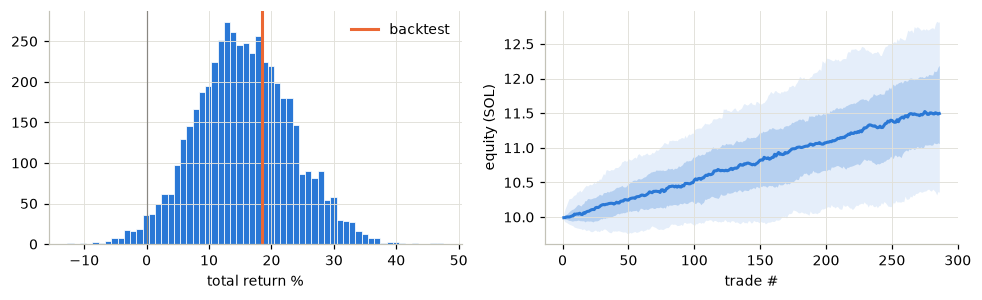

P(loss) 0.02 · P(ruin) 0.000


In [7]:
from pumpfun_hft.backtester.engine import BacktestEngine
from pumpfun_hft.backtester.replay import DataSource
from pumpfun_hft.analytics.montecarlo import trade_monte_carlo
bt = BacktestEngine(settings, DataSource(frame=events), ["smart_money"], metadata=data.metadata, synthetic=True).run()
mc = trade_monte_carlo(bt.trades, bt.initial_capital_sol, bt.metrics["span_days"], settings.montecarlo, bt.metrics["avg_latency_ms"], 5000)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 2.8))
a1.hist(100 * mc.distributions["total_return"], bins=60, color=BLUE, edgecolor="white", linewidth=0.5)
a1.axvline(100 * bt.metrics["total_return"], color=ORANGE, lw=2, label="backtest"); a1.axvline(0, color=GRAY, lw=0.8)
a1.set_xlabel("total return %"); a1.legend(frameon=False)
q = np.quantile(mc.paths, [0.05, 0.25, 0.5, 0.75, 0.95], axis=0); x = np.arange(1, q.shape[1] + 1)
a2.fill_between(x, q[0], q[4], color=BLUE, alpha=0.12, lw=0); a2.fill_between(x, q[1], q[3], color=BLUE, alpha=0.25, lw=0)
a2.plot(x, q[2], color=BLUE, lw=2); a2.set_xlabel("trade #"); a2.set_ylabel("equity (SOL)")
plt.tight_layout(); plt.show()
print(f"P(loss) {mc.prob_loss:.2f} · P(ruin) {mc.prob_ruin:.3f}")